## Urban Infrastructure Failure Risk (ITNPBD6) — Practice Notebook

### Sections

- Section 0: Setup & configuration\n
- Section 1: Load and inspect data\n
- Section 2: Train/validate/test split\n
- Section 3: Variable table + preprocessing choices\n
- Section 4: Data cleaning via histogram (before/after)\n
- Section 5: Build feature matrices + scaling\n
- Section 6: Logistic regression\n
- Section 7: Decision tree\n
- Section 8: Neural network (Keras)\n
- Section 9: Compare models + pick final\n
- Section 10: Final test evaluation + confusion matrix\n
- Section 11: Additional insight\n
- Section 12: References\n

### Section 0: Library Imports and Configuration


In [1]:
# I start by importing data manipulation libraries
import pandas as pd
import numpy as np

# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Importing maching learning libraries and required classes for assignment
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Now I import Keras via tensorflow which is a deeplearning library
from tensorflow import keras

# To ensure the result reproducibility, i use RANDOM_STATE in sklearn and keras
RANDOM_STATE = 42


### Section 1: Data Loading and EDA

In [2]:
# I start by loading the data from csv into dataframe 'df'
df = pd.read_csv("urbandata.csv")
print("Shape (rows, cols):", df.shape)
print("Columns:", df.columns.tolist())

#Check the entries of the dataset
df.head()




Shape (rows, cols): (456, 12)
Columns: ['inspector_id', 'material_flexibility', 'structural_mass_ratio', 'recent_precipitation', 'infrastructure_age', 'surface_debris', 'vibration_exposure', 'asset_density', 'inspection_season', 'inspection_window', 'moisture_stress', 'failure']


,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [3]:
# Now I check the data types of variables
df.dtypes

inspector_id               int64
material_flexibility     float64
structural_mass_ratio    float64
recent_precipitation     float64
infrastructure_age       float64
surface_debris           float64
vibration_exposure       float64
asset_density            float64
inspection_season         object
inspection_window         object
moisture_stress          float64
failure                    int64
dtype: object

In [4]:
# Counting missing values in each column
missing = df.isnull().sum()
# Now show columns with missing values only
missing = missing[missing>0].sort_values(ascending=False)
# Now lets print the columns with missing values only
print(missing)

infrastructure_age       4
moisture_stress          3
recent_precipitation     2
structural_mass_ratio    1
vibration_exposure       1
dtype: int64


In [5]:
# Now I check the target variable count and percentage
target_counts = df["failure"].value_counts().sort_index()
target_pct = df["failure"].value_counts(normalize=True).mul(100).round(2)
# Now I print the target variable count and percentage
print(target_counts)
print(target_pct)



failure
0    288
1    168
Name: count, dtype: int64
failure
0    63.16
1    36.84
Name: proportion, dtype: float64


inspector_id is treated as as identifier; candidate to drop before modeling.


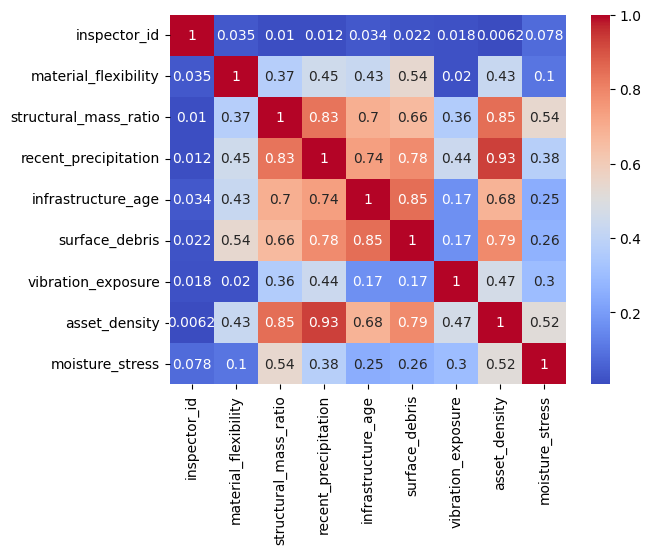

In [6]:
""" 
Now I will check the redundant columns and the ones having high correlation among themselves
I will start by flagging the identifier column
"""

# inspector_id is an ID, not a physical predictor.
print("inspector_id is treated as as identifier; candidate to drop before modeling.")

# Build numeric-only DataFrame and exclude target variable column
num_df = df.select_dtypes(include=["number"]).drop(columns=["failure"], errors="ignore")

# Now i calculate the absolute correlation between the columns
corr_matrix = num_df.corr().abs()
# Now i plot the correlation matrix using seaborn heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()


In [7]:
# Keep upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
upper

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,moisture_stress
inspector_id,NaN,0.034561,0.010414,0.011658,0.033680,0.021902,0.018135,0.006196,0.078406
material_flexibility,NaN,NaN,0.373450,0.450342,0.427320,0.540810,0.019700,0.427772,0.103187
structural_mass_ratio,NaN,NaN,NaN,0.833709,0.695421,0.661239,0.359906,0.845429,0.544956
recent_precipitation,NaN,NaN,NaN,NaN,0.738631,0.783012,0.439691,0.930145,0.375599
infrastructure_age,NaN,NaN,NaN,NaN,NaN,0.845629,0.167299,0.683343,0.246981
surface_debris,NaN,NaN,NaN,NaN,NaN,NaN,0.168003,0.789815,0.264388
vibration_exposure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.466034,0.298871
asset_density,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.515323
moisture_stress,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Flatten matrix to sorted pairs.
high_corr_pairs = upper.stack().sort_values(ascending=False)

# Filter very high correlations.
high_corr_pairs = high_corr_pairs[high_corr_pairs >= 0.85]

# Now i print the high correlation pairs result.
print("High-correlation pairs (>= 0.85):")
print(high_corr_pairs if not high_corr_pairs.empty else "None")





High-correlation pairs (>= 0.85):
recent_precipitation  asset_density    0.930145
dtype: float64


### Section 2: Train, Validate & Test Split

In [10]:
"""
I will start by creating the training, validation and testing datasets of Failure using statify
hyperparameter so that the each split keeps roughly the same propotion of each class 
as given in main dataset.
"""
# I will start by using target for stratified split
y = df['failure']

# First split: train+val (80%) and test (20%).
train_val, test_df = train_test_split(df, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Second split: from train+val, create train (80%) and val (20%).
train_df, val_df = train_test_split(train_val, test_size=0.2, stratify=train_val["failure"], random_state=RANDOM_STATE)


In [ ]:
"""
Now I will show how many rows are in each split as a result of above tain-test 
splitting excercise. We show class counts and percentages both.
"""
# Print split sizes.
print("Train size:", len(train_df), "| Val size:", len(val_df), "| Test size:", len(test_df))

# Train class distribution.
train_counts = train_df["failure"].value_counts().sort_index()
train_pct = train_df["failure"].value_counts(normalize=True).sort_index().mul(100).round(2)
print("\nTrain counts:\n", train_counts)
print("Train %:\n", train_pct)

# Validation class distribution.
val_counts = val_df["failure"].value_counts().sort_index()
val_pct = val_df["failure"].value_counts(normalize=True).sort_index().mul(100).round(2)
print("\nVal counts:\n", val_counts)
print("Val %:\n", val_pct)

# Test class distribution.
test_counts = test_df["failure"].value_counts().sort_index()
test_pct = test_df["failure"].value_counts(normalize=True).sort_index().mul(100).round(2)
print("\nTest counts:\n", test_counts)
print("Test %:\n", test_pct)

